# Task 2: Exploratory Data Analysis (EDA)

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn requests

In [ ]:
# Download the dataset
import requests
url = 'https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv'
response = requests.get(url)
with open('dontpatronizeme_pcl.tsv', 'wb') as f:
    f.write(response.content)
print('Downloaded dontpatronizeme_pcl.tsv')

Dataset downloaded as data/dontpatronizeme_pcl.tsv


## Class Distribution Analysis

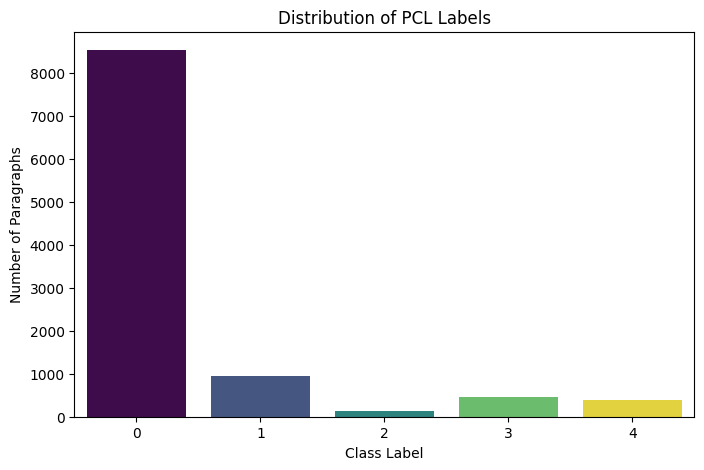

label
0    81.469099
1     9.045754
2     1.375490
3     4.374821
4     3.734836
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Skip the first 4 disclaimer lines when reading the TSV
df = pd.read_csv('./data/dontpatronizeme_pcl.tsv', sep='\t', header=None, skiprows=4, names=['line', 'id', 'keyword', 'country', 'text', 'label'])

print(df['label'].value_counts(normalize=True).sort_index() * 100)

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Distribution of PCL Labels')
plt.xlabel('Class Label')
plt.ylabel('Number of Paragraphs')
plt.show()

## 2. Lexical Analysis: N-gram Profiling

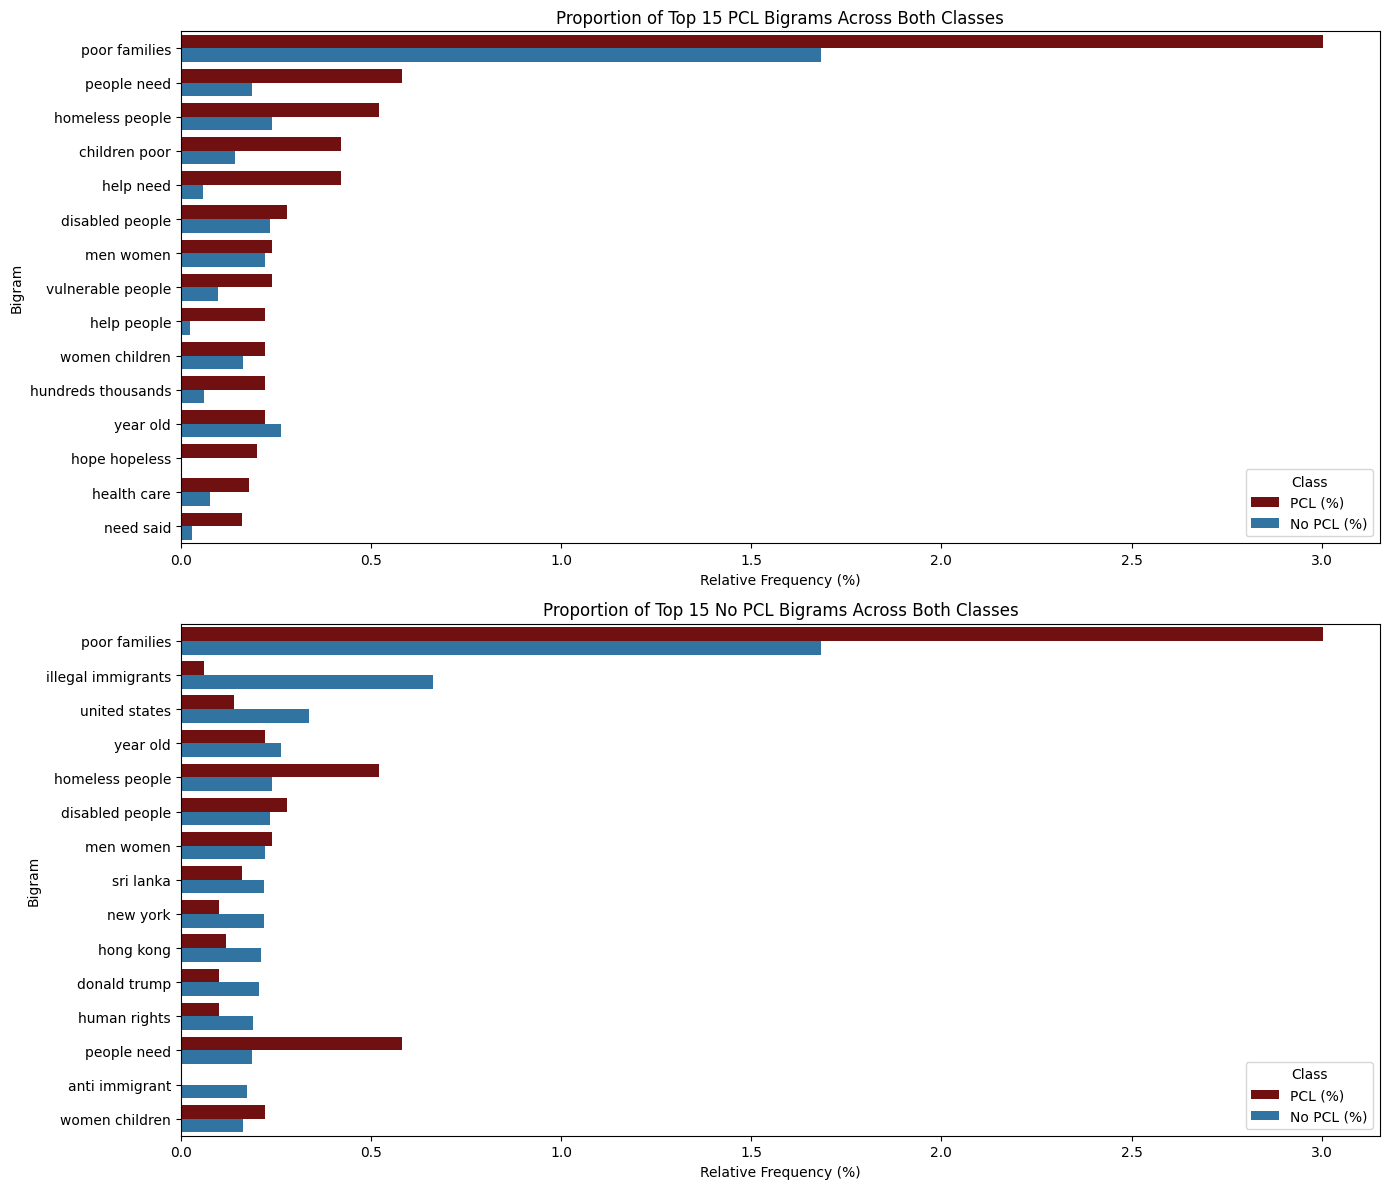

In [34]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

df['binary_label'] = df['label'].apply(lambda x: 0 if x in [0, 1] else 1)

# Fit a vectorizer on all text so the vocabulary matches across both classes
vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', min_df=2)
clean_df = df.dropna(subset=['text'])
X = vec.fit_transform(clean_df['text'])
vocab = vec.get_feature_names_out()

# Get masks for classes
pcl_mask = (clean_df['binary_label'] == 1).values
nopcl_mask = (clean_df['binary_label'] == 0).values

# Calculate raw sums
pcl_sums = np.array(X[pcl_mask].sum(axis=0))[0]     # type: ignore
nopcl_sums = np.array(X[nopcl_mask].sum(axis=0))[0] # type: ignore

# Normalise to proportions (Percentage of total bigrams in that class)
pcl_total = pcl_sums.sum()
nopcl_total = nopcl_sums.sum()

pcl_props = (pcl_sums / pcl_total) * 100
nopcl_props = (nopcl_sums / nopcl_total) * 100

# Create a unified DataFrame
bigram_df = pd.DataFrame({
    'Bigram': vocab, 
    'PCL (%)': pcl_props, 
    'No PCL (%)': nopcl_props
})

# Extract Top 15 for each class
top_pcl = bigram_df.sort_values(by='PCL (%)', ascending=False).head(15)
top_nopcl = bigram_df.sort_values(by='No PCL (%)', ascending=False).head(15)

# Melt the dataframes for Seaborn's grouped barplot format
melted_pcl = top_pcl.melt(id_vars='Bigram', value_vars=['PCL (%)', 'No PCL (%)'], var_name='Class', value_name='Proportion')
melted_nopcl = top_nopcl.melt(id_vars='Bigram', value_vars=['PCL (%)', 'No PCL (%)'], var_name='Class', value_name='Proportion')

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Graph 1: Top 15 PCL Bigrams compared to their presence in No PCL
sns.barplot(x='Proportion', y='Bigram', hue='Class', data=melted_pcl, palette=['#800000', '#1f77b4'], ax=axes[0])
axes[0].set_title('Proportion of Top 15 PCL Bigrams Across Both Classes')
axes[0].set_xlabel('Relative Frequency (%)')

# Graph 2: Top 15 No PCL Bigrams compared to their presence in PCL
sns.barplot(x='Proportion', y='Bigram', hue='Class', data=melted_nopcl, palette=['#800000', '#1f77b4'], ax=axes[1])
axes[1].set_title('Proportion of Top 15 No PCL Bigrams Across Both Classes')
axes[1].set_xlabel('Relative Frequency (%)')

plt.tight_layout()
plt.show()